In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [3]:
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [4]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


In [6]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform_test)

In [7]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

In [8]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,32,kernel_size = 3,padding = 1)
        self.conv2 = nn.Conv2d(32,64,kernel_size = 3,padding = 1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64*7*7,128)
        self.fc2 = nn.Linear(128,10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self,x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = torch.flatten(x,start_dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device(type='cpu')

In [11]:
from tqdm import tqdm

num_epochs = 10
train_loss_history = []
test_loss_history = []
test_accuracy_history = []

for epoch in range(num_epochs):
    # ===== ОБУЧЕНИЕ =====
    model.train()
    running_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{num_epochs}")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        train_bar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    train_loss = running_loss / len(train_loader)
    train_loss_history.append(train_loss)

    # ===== ВАЛИДАЦИЯ =====
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    
    val_bar = tqdm(test_loader, desc=f"Val Epoch {epoch+1}/{num_epochs}")
    with torch.no_grad():
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            val_bar.set_postfix({'acc': f"{100 * correct / total:.2f}%"})

    test_loss = test_loss / len(test_loader)
    test_loss_history.append(test_loss)
    test_accuracy = 100 * correct / total
    test_accuracy_history.append(test_accuracy)

    # Печатаем итоги эпохи
    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

Val Epoch 1/10: 100%|██████████| 79/79 [00:06<00:00, 12.59it/s, acc=98.32%]


Epoch 1: Train Loss: 0.1899, Test Loss: 0.0533, Test Accuracy: 98.32%


Val Epoch 2/10: 100%|██████████| 79/79 [00:05<00:00, 13.36it/s, acc=98.80%]


Epoch 2: Train Loss: 0.0582, Test Loss: 0.0368, Test Accuracy: 98.80%


Val Epoch 3/10: 100%|██████████| 79/79 [00:05<00:00, 13.21it/s, acc=98.84%]


...

Epoch 8: Train Loss: 0.0164, Test Loss: 0.0238, Test Accuracy: 99.24%


Val Epoch 9/10: 100%|██████████| 79/79 [00:06<00:00, 12.91it/s, acc=99.27%]


Epoch 9: Train Loss: 0.0120, Test Loss: 0.0253, Test Accuracy: 99.27%


Val Epoch 10/10: 100%|██████████| 79/79 [00:05<00:00, 13.27it/s, acc=99.17%]

Epoch 10: Train Loss: 0.0122, Test Loss: 0.0287, Test Accuracy: 99.17%


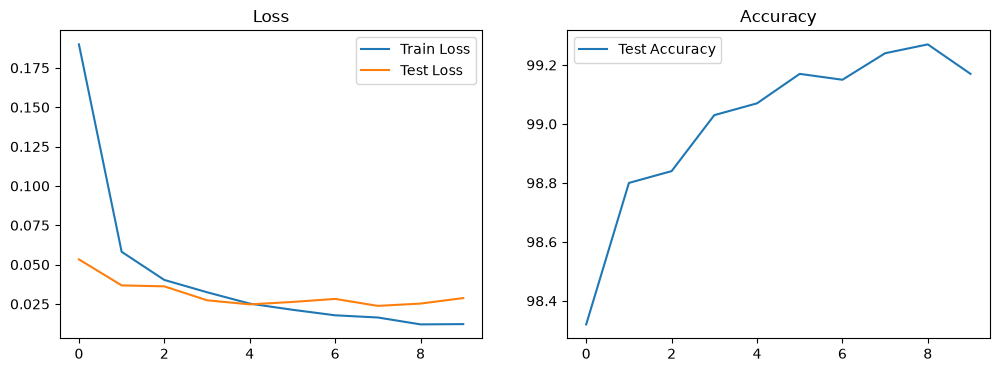

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(test_loss_history, label='Test Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(test_accuracy_history, label='Test Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

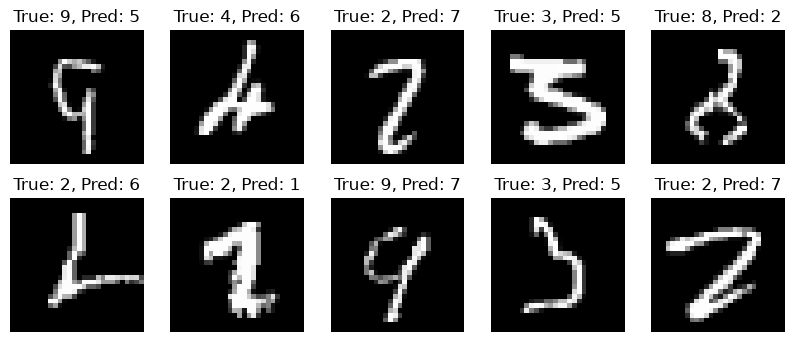

In [13]:
model.eval()
mistakes = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                mistakes.append((images[i].cpu(), labels[i].cpu(), predicted[i].cpu()))

# Показать первые 10 ошибок
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, (img, true, pred) in enumerate(mistakes[:10]):
    row, col = i // 5, i % 5
    axes[row, col].imshow(img.squeeze(), cmap='gray')
    axes[row, col].set_title(f"True: {true}, Pred: {pred}")
    axes[row, col].axis('off')
plt.show()

In [14]:
import torch
import torch.nn as nn

# Свёрточный слой
conv = nn.Conv2d(1, 1, kernel_size=3, bias=False)

# Входное изображение
x = torch.randn(1, 1, 5, 5, requires_grad=True)

# Прямой проход
y = conv(x)

# Функция потерь (просто сумма для примера)
loss = y.sum()

# Обратный проход
loss.backward()

# Градиент по весам ядра
print(conv.weight.grad)  # ➜ Не None! Градиент есть!

tensor([[[[-1.7608,  0.4256,  0.2449],
          [-0.0872, -1.8044, -2.7212],
          [-1.4980, -1.9931, -2.8827]]]])


## Cifar10

In [15]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


In [16]:
# ===== 1. ТРАНСФОРМАЦИИ =====
# Для обучения (с аугментацией)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),   # случайное отражение по горизонтали (увеличивает выборку)
    transforms.RandomCrop(32, padding=4),  # случайный кроп с добавлением 4 пикселей по краям
    transforms.ToTensor(),                # преобразуем PIL Image в тензор (0-255 -> 0-1)
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))  # нормализация по каналам
])

In [17]:
# Для теста (только нормализация)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

In [18]:

# ===== 2. ЗАГРУЗКА ДАННЫХ =====
trainset = torchvision.datasets.CIFAR10(
    root='./data',        # папка для сохранения датасета
    train=True,
    download=True,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

  1%|          | 1.11M/170M [00:18<46:47, 60.3kB/s]


KeyboardInterrupt: 

In [ ]:


# ===== 3. СОЗДАНИЕ ЗАГРУЗЧИКОВ (DATALOADER) =====
train_loader = DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True      # ускоряет перенос данных на GPU
)

test_loader = DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ===== 4. ПРОВЕРКА РАЗМЕРОВ =====
print(f"Размер обучающей выборки: {len(trainset)}")
print(f"Размер тестовой выборки: {len(testset)}")

# Пример одного батча
images, labels = next(iter(train_loader))
print(f"Форма батча: {images.shape}")  # [batch_size, channels, height, width]
print(f"Метки: {labels[:10]}")

In [20]:


class CifarCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,kernel_size = 3,padding = 1)
        self.conv2 = nn.Conv2d(32,64,kernel_size = 3,padding = 1)
        self.conv3 = nn.Conv2d(64,128,kernel_size = 3,padding = 1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(128*4*4,256)
        self.fc2 = nn.Linear(256,10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self,x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)

        x = torch.flatten(x,start_dim=1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device
model = CifarCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)